Main file for simulating photodiode response to incident light. Pulls functions from respective files. Each physcal phenomena corresponds to a given function

Docstring formatting in NumPy style: https://numpydoc.readthedocs.io/en/latest/format.html
Python formatting in PEP-8: https://pep8.org/ (but tabs instead of spaces, duh)

24/04/2026: Start of version control.
Current modules:
Optical: absorbance, eta, flux, generation_rate, light_source

Eletrical: Not added yet.

light_source defines the incident light source, takes either a constant or a pulse.\
absorbance computes the alpha with a given wavelength
eta computes the quantum efficiency for a given wavelength
flux computes the number of photons from the light source
generation rate computes the number of generated carriers

dn/dt is the main differentail equation to be solved.

Branched out to add several things: 
Pulsed input: Change alpha, qe, flux to be computed at a timestep, not as a constant.

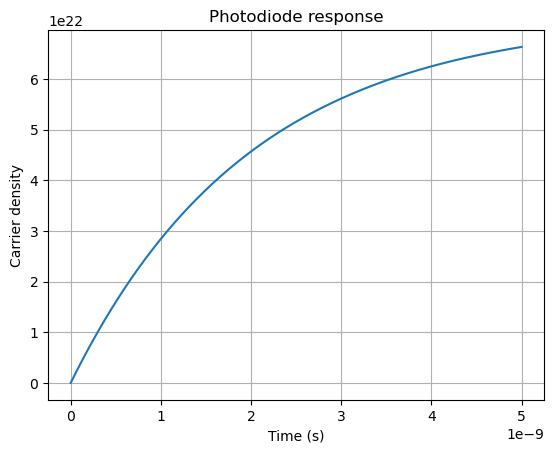

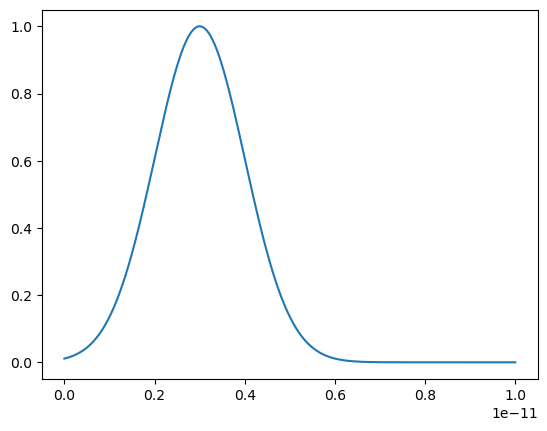

In [ ]:
import numpy as np
import scipy as sci
import matplotlib.pyplot as plt

import constants
from absorbance import absorbance
from eta import eta
from flux import flux
from generation_rate import generation_rate
from light_source import LightSource

# input paramaeters
P_mW = 1.0
P = P_mW * 1e-3    # convert to W
lam = 850e-9       # wavelength in meters
tau = 2e-9         # carrier lifetime (s)

# geometry of structure
A = 1e-10      # m^2 (e.g. 10 µm x 10 µm)
d = 100e-9     # 100 nm depth profile

# define pulse shape
t_pulse   = np.linspace(0, 10e-12, 1000)
tau_pulse = 1e-12
t0        = 3e-12
envelope  = np.exp(-((t_pulse - t0)**2) / (2 * tau_pulse**2))

# CW source
cw_source = LightSource(P=P, lam=lam, bandwidth=0, area=A, mode='cw')

# pulsed source
pulsed_source = LightSource(
    P         = P,
    lam       = lam,
    bandwidth = 0,
    area      = A,
    mode      = 'pulsed',
    pulse_t   = t_pulse,
    pulse_env = envelope,
)

# Main eval folder
def dn_dt(t, n):
    alpha = absorbance(pulsed_source.lam, model="beer_lambert", alpha_0=1e6)
    qe = eta(pulsed_source.lam, model='unity')
    phi   = flux(pulsed_source, t, model='monochromatic')
    G_z   = generation_rate(z, qe, alpha, phi, model="beer_lambert")
    G_avg = np.trapezoid(G_z, z) / d
    return G_avg - n / tau

# evaluation parameters
t_span = (0, 50e-12)
t_eval = np.linspace(0, 50e-12, 1000)
z = np.linspace(0, d, 500)

if __name__ == "__main__":
    sol = sci.integrate.solve_ivp(
    dn_dt, t_span, [0],
    t_eval  = t_eval,
    )   

    plt.plot(sol.t, sol.y[0])
    plt.xlabel("Time (s)")
    plt.ylabel("Carrier density")
    plt.title("Photodiode response")
    plt.grid()
    
plt.figure()
plt.plot(pulsed_source.pulse_t, pulsed_source.pulse_env)